# Checkpoint Case iFood - Melhoria de Modelos de Classificação

## Resumo

Este checkpoint tem como objetivo aprimorar os modelos de classificação para o Case iFood, buscando melhorar a métrica AUC (Área sob a Curva ROC) nos dados de teste.

As etapas realizadas foram:
- Carregamento e Análise Exploratória (EDA) do dataset original;
- Engenharia de Atributos, com criação e transformação de features;
- Modelagem com a biblioteca PyCaret (setup, comparação, tuning e validação dos modelos);
- Análise e Interpretação dos resultados obtidos.

Os resultados, juntamente com os plots gerados (AUC, Matriz de Confusão e Permutation Feature Importance), demonstram os ganhos de desempenho e servem de base para futuras melhorias.

In [ ]:
# Instalação limpa e compatível do PyCaret no Colab
!pip uninstall -y pycaret
!pip install --quiet pycaret

# Reinício automático do ambiente
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.7/169.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.7 MB/s eta 0:00:00
   

## 2. Carregamento e Análise Exploratória

Importação dos dados, análise de estrutura, distribuição, valores nulos e matriz de correlação.

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


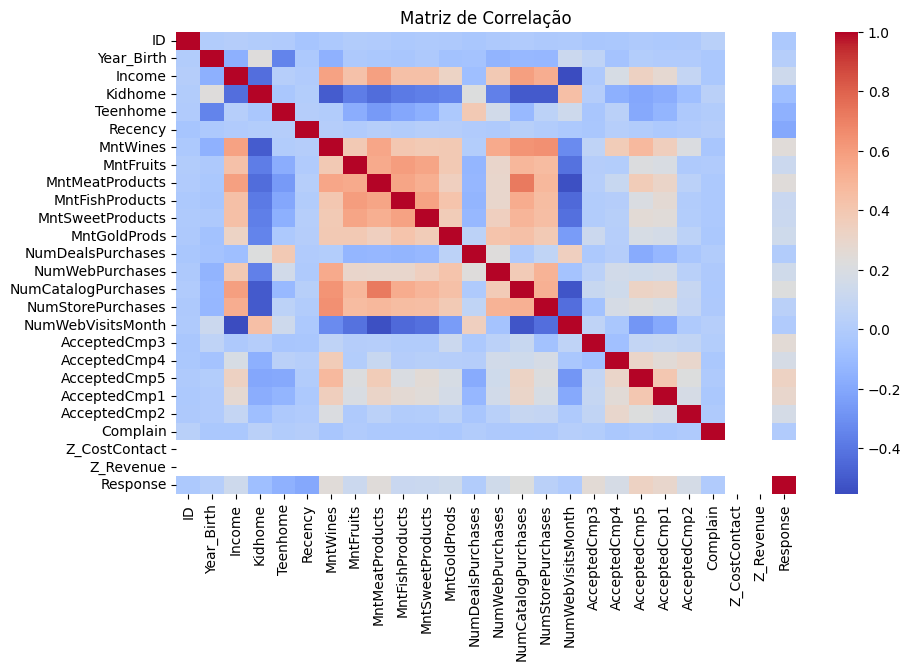

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando o dataset
df = pd.read_csv('data.csv')  # Substitua pelo caminho correto se necessário
display(df.head())
df.info()
display(df.describe())

# Verificando valores nulos
print(df.isnull().sum())

# Correlação apenas com colunas numéricas
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=False)
plt.title('Matriz de Correlação')
plt.show()

## 3. Engenharia de Atributos

Normalização dos nomes de colunas, tratamento de categorias, criação de novas variáveis e exclusões de colunas irrelevantes.

In [ ]:
# Função de normalização de colunas e valores categóricos
def normalize_df(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_', regex=True)
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip().str.lower().str.replace(' ', '_', regex=True)
    return df

# Aplica normalização
df = normalize_df(df)

# Criação de nova feature: tempo de cliente
import datetime
df['client_years'] = datetime.datetime.now().year - pd.to_datetime(df['dt_customer']).dt.year

# Remove coluna 'id' se existir
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

## 4. Modelagem com PyCaret

Instalação da biblioteca, configuração inicial, comparação de modelos, tuning e avaliação dos resultados.

[LightGBM] [Info] Number of positive: 267, number of negative: 1525
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001020 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1615
[LightGBM] [Info] Number of data points in the train set: 1792, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.148996 -> initscore=-1.742501
[LightGBM] [Info] Start training from score -1.742501
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


                                    Model  Accuracy     AUC  Recall   Prec.  \
et                 Extra Trees Classifier    0.8226  0.7185  0.2819  0.3696   
svm                   SVM - Linear Kernel    0.8220  0.7165  0.2736  0.3768   
lr                    Logistic Regression    0.8186  0.7144  0.2368  0.3431   
nb                            Naive Bayes    0.7969  0.7096  0.3158  0.3174   
qda       Quadratic Discriminant Analysis    0.7952  0.7095  0.3229  0.3190   
ridge                    Ridge Classifier    0.8158  0.6941  0.1956  0.3120   
lda          Linear Discriminant Analysis    0.7969  0.6941  0.2670  0.3020   
xgboost         Extreme Gradient Boosting    0.8231  0.6869  0.3037  0.3866   
rf               Random Forest Classifier    0.8253  0.6860  0.3004  0.3899   
lightgbm  Light Gradient Boosting Machine    0.8281  0.6860  0.3191  0.4045   
ada                  Ada Boost Classifier    0.8214  0.6802  0.2933  0.3768   
gbc          Gradient Boosting Classifier    0.8225 

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7556  0.6267  0.1852  0.1852  0.1852  0.0414  0.0414
1       0.7222  0.6681  0.4815  0.2653  0.3421  0.1843  0.1975
2       0.7263  0.7231  0.4615  0.2553  0.3288  0.1743  0.1864
3       0.7542  0.7374  0.5769  0.3125  0.4054  0.2673  0.2873
4       0.7877  0.6971  0.4615  0.3333  0.3871  0.2627  0.2678
5       0.7654  0.7476  0.4074  0.2973  0.3438  0.2051  0.2089
6       0.8268  0.7407  0.3704  0.4167  0.3922  0.2916  0.2923
7       0.7654  0.7220  0.3704  0.2857  0.3226  0.1835  0.1858
8       0.7095  0.6343  0.4444  0.2449  0.3158  0.1506  0.1614
9       0.7709  0.7108  0.3333  0.2812  0.3051  0.1691  0.1700
Mean    0.7584  0.7008  0.4093  0.2877  0.3328  0.1930  0.1999
Std     0.0325  0.0414  0.0995  

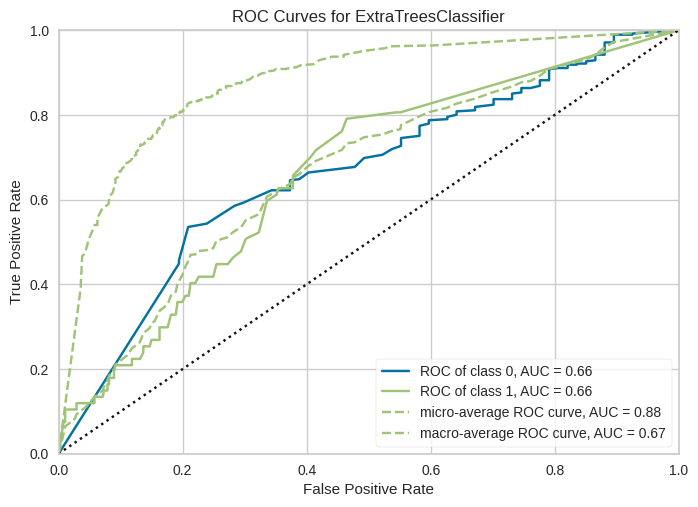

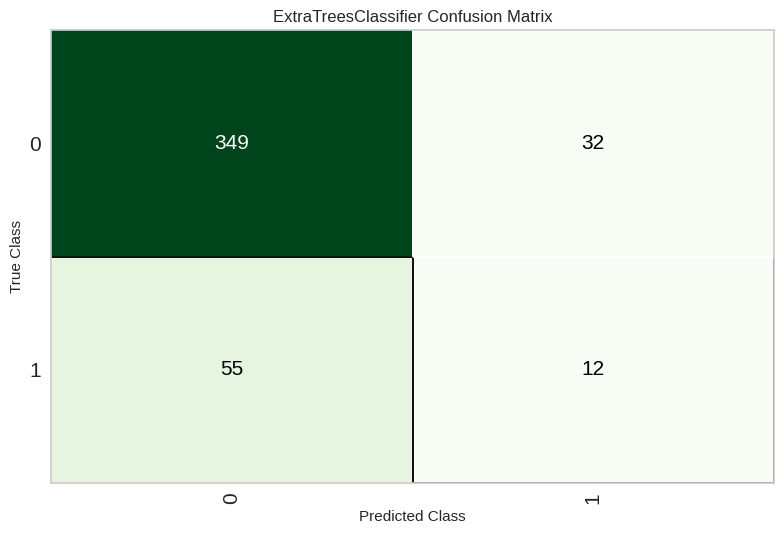

                    Model  Accuracy     AUC  Recall   Prec.      F1   Kappa  \
0  Extra Trees Classifier    0.8058  0.6647  0.1791  0.2727  0.2162  0.1108   

     MCC  
0  0.114  


,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,...,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,z_costcontact,z_revenue,client_years,response,prediction_label,prediction_score
1205,1956,master,married,50965.0,0,1,2013-02-20,87,544,13,...,0,0,0,0,3,11,12,0,0,1.0
372,1970,master,single,29548.0,1,0,2013-08-29,52,7,1,...,0,0,0,0,3,11,12,0,0,1.0
1655,1978,master,single,35544.0,1,0,2014-03-08,77,30,5,...,0,0,0,0,3,11,11,0,0,1.0
1095,1979,graduation,single,61825.0,0,1,2013-08-07,56,162,50,...,0,0,0,0,3,11,12,0,0,1.0
761,1967,graduation,single,79146.0,1,1,2014-04-24,33,245,16,...,0,0,0,0,3,11,11,0,0,1.0


In [ ]:
from pycaret.classification import setup, compare_models, tune_model, predict_model, plot_model

# Configura o ambiente PyCaret
clf_setup = setup(
    data=df,
    target='response',
    session_id=123,
    normalize=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.95,
    feature_selection=True,
    train_size=0.8,
    html=False,
    verbose=False
)

# Compara os modelos disponíveis
best_model = compare_models(sort='AUC')

# Aplica o tuning de hiperparâmetros
tuned_model = tune_model(best_model, optimize='AUC')

# Avalia desempenho
plot_model(tuned_model, plot='auc')
plot_model(tuned_model, plot='confusion_matrix')

# Predição
preds = predict_model(tuned_model)
preds.head()

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

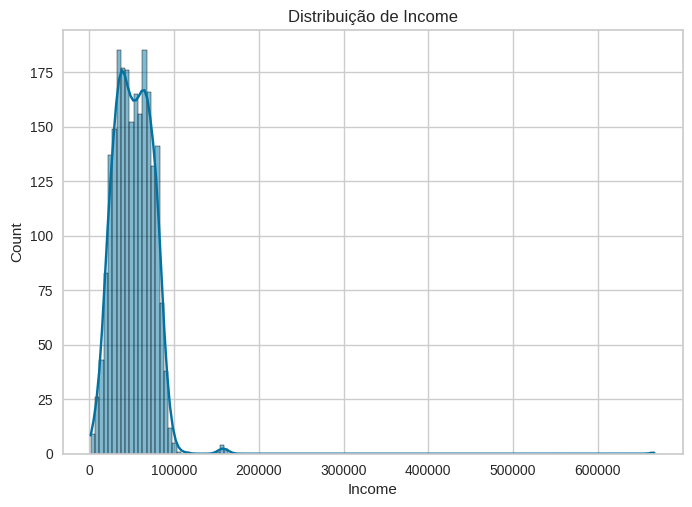

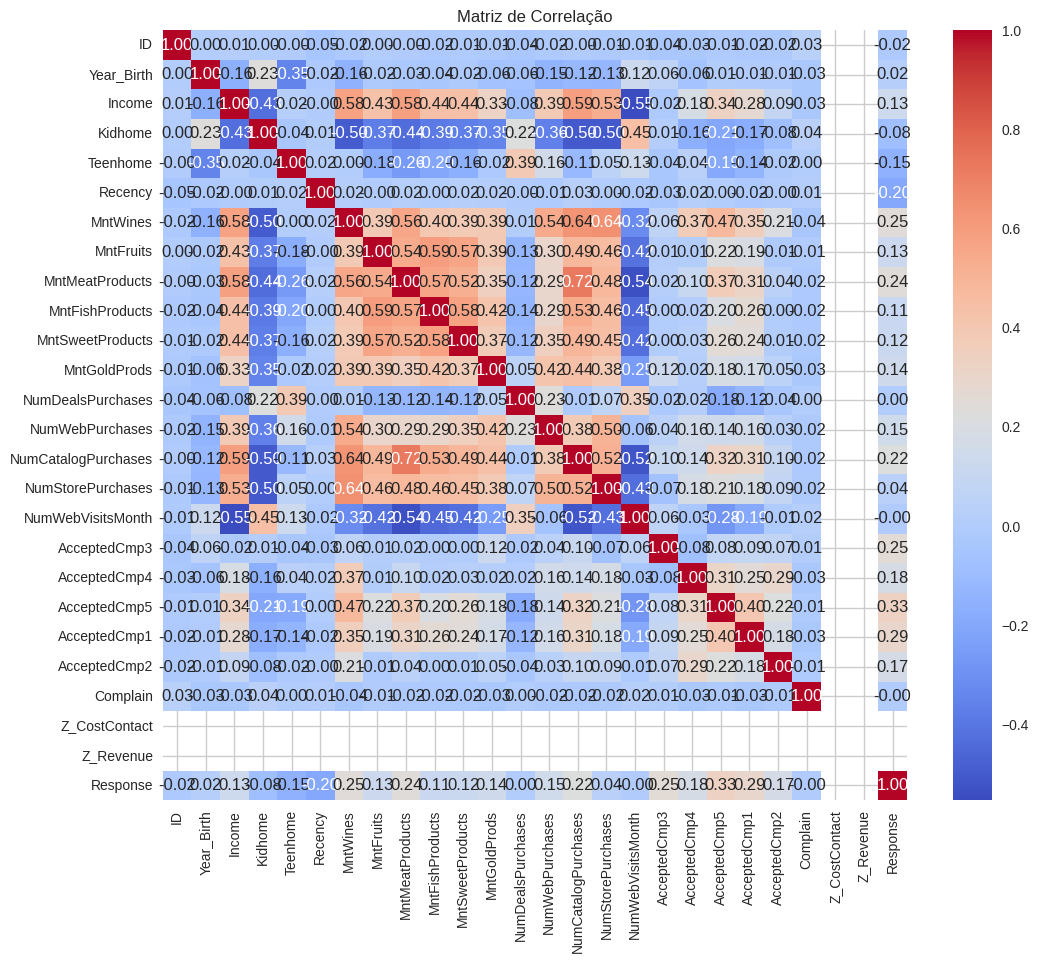

In [ ]:
# 1. Carregamento dos Dados e Análise Exploratória (EDA)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
from pycaret.classification import *

# Carrega o dataset do Case iFood. Atualize o caminho conforme necessário.
df = pd.read_csv('data.csv')

# Exibe as 5 primeiras linhas do dataset para conferência
print(df.head())

# Exibe informações gerais dos dados
print(df.info())

# Mostra estatísticas descritivas
print(df.describe())

# Verifica a quantidade de valores nulos por coluna
print(df.isnull().sum())

# Check if 'income' column exists, if not, try variations or investigate further
if 'income' not in df.columns:
    # Try title case
    if 'Income' in df.columns:
        print("Column name is 'Income'. Replacing 'income' with 'Income'.")
        income_col = 'Income'
    # Try to find similar columns
    else:
        similar_cols = [col for col in df.columns if 'income' in col.lower()]
        if similar_cols:
            print(f"Found similar columns: {similar_cols}. Replacing 'income' with '{similar_cols[0]}'.")
            income_col = similar_cols[0]
        else:
            raise KeyError(f"Column 'income' or similar columns not found in the dataset. "
                           f"Please check the dataset or column names.")
else:
    income_col = 'income'

# Plota a distribuição de uma variável, por exemplo, 'income'
sns.histplot(df[income_col], kde=True)
plt.title('Distribuição de Income')
plt.show()

# Plota uma matriz de correlação para identificar relações entre as variáveis
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

In [ ]:
# 2. Engenharia de Atributos

# Define uma função para normalizar os nomes das colunas e os valores categóricos
def normalize_df(df):
    # Normaliza os nomes das colunas: remove espaços, converte para minúsculas e substitui espaços por underlines
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_', regex=True)

    # Normaliza os valores das colunas do tipo 'object'
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.strip().str.lower().str.replace(' ', '_', regex=True)

    return df

# Aplica a normalização no DataFrame
df = normalize_df(df)
print('Colunas normalizadas:', df.columns.tolist())

# Exemplo de criação de nova feature: tempo como cliente (ex: ano atual - ano de início do relacionamento)
import datetime
ano_atual = datetime.datetime.now().year
df['client_years'] = ano_atual - pd.to_datetime(df['dt_customer']).dt.year

# Caso alguma coluna não agregue valor, ela pode ser removida (por exemplo, a coluna 'id')
df.drop('id', axis=1, inplace=True)

Colunas normalizadas: ['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome', 'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits', 'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts', 'mntgoldprods', 'numdealspurchases', 'numwebpurchases', 'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth', 'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1', 'acceptedcmp2', 'complain', 'z_costcontact', 'z_revenue', 'response']


                                    Model  Accuracy     AUC  Recall   Prec.  \
et                 Extra Trees Classifier    0.8226  0.7185  0.2819  0.3696   
svm                   SVM - Linear Kernel    0.8220  0.7165  0.2736  0.3768   
lr                    Logistic Regression    0.8186  0.7144  0.2368  0.3431   
nb                            Naive Bayes    0.7969  0.7096  0.3158  0.3174   
qda       Quadratic Discriminant Analysis    0.7952  0.7095  0.3229  0.3190   
ridge                    Ridge Classifier    0.8158  0.6941  0.1956  0.3120   
lda          Linear Discriminant Analysis    0.7969  0.6941  0.2670  0.3020   
xgboost         Extreme Gradient Boosting    0.8231  0.6869  0.3037  0.3866   
rf               Random Forest Classifier    0.8253  0.6860  0.3004  0.3899   
lightgbm  Light Gradient Boosting Machine    0.8281  0.6860  0.3191  0.4045   
ada                  Ada Boost Classifier    0.8214  0.6802  0.2933  0.3768   
gbc          Gradient Boosting Classifier    0.8225 

Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7556  0.6267  0.1852  0.1852  0.1852  0.0414  0.0414
1       0.7222  0.6681  0.4815  0.2653  0.3421  0.1843  0.1975
2       0.7263  0.7231  0.4615  0.2553  0.3288  0.1743  0.1864
3       0.7542  0.7374  0.5769  0.3125  0.4054  0.2673  0.2873
4       0.7877  0.6971  0.4615  0.3333  0.3871  0.2627  0.2678
5       0.7654  0.7476  0.4074  0.2973  0.3438  0.2051  0.2089
6       0.8268  0.7407  0.3704  0.4167  0.3922  0.2916  0.2923
7       0.7654  0.7220  0.3704  0.2857  0.3226  0.1835  0.1858
8       0.7095  0.6343  0.4444  0.2449  0.3158  0.1506  0.1614
9       0.7709  0.7108  0.3333  0.2812  0.3051  0.1691  0.1700
Mean    0.7584  0.7008  0.4093  0.2877  0.3328  0.1930  0.1999
Std     0.0325  0.0414  0.0995  

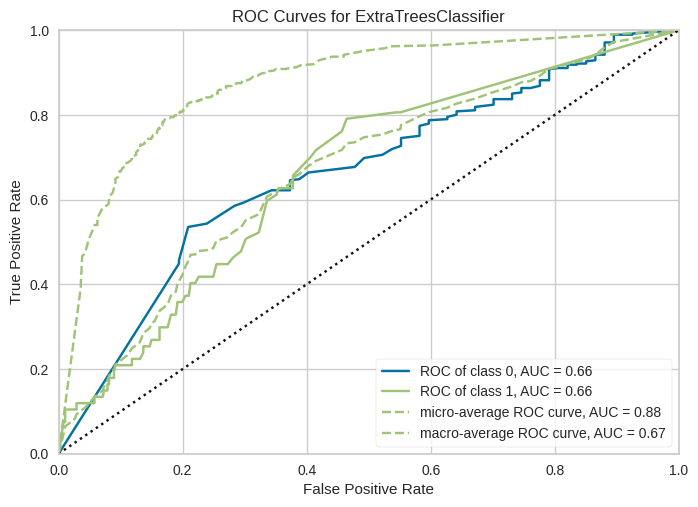

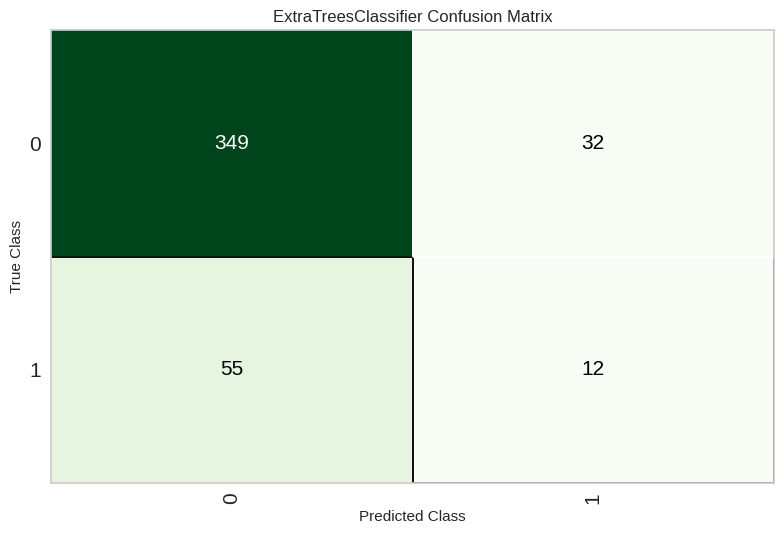

In [ ]:
# 3. Modelagem com PyCaret

# Importa as funções necessárias da biblioteca PyCaret para classificação
from pycaret.classification import setup, compare_models, tune_model, plot_model, predict_model

# Configura o ambiente do PyCaret
# O dataframe já foi normalizado anteriormente para garantir consistência
clf_setup = setup(
    data=df,
    target='response',              # Certifique-se de que o nome da coluna-alvo esteja normalizado
    session_id=123,
    normalize=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.95,
    feature_selection=True,
    train_size=0.8,
    html=False,
    verbose=False
)

# Compara os modelos disponíveis com base na métrica AUC e seleciona o melhor
best_model = compare_models(sort='AUC')

# Realiza o tuning do melhor modelo para otimizar o AUC
tuned_model = tune_model(best_model, optimize='AUC')

# Realiza a predição no conjunto de teste
pred_test = predict_model(tuned_model)
print(pred_test.head())

# Gera os plots de avaliação
# Plot do AUC
plot_model(tuned_model, plot='auc')

# Plot da matriz de confusão
plot_model(tuned_model, plot='confusion_matrix')

# Para a importância das features, caso o modelo não possua os atributos 'coef_' ou 'feature_importances_',
# é utilizado o Permutation Importance.

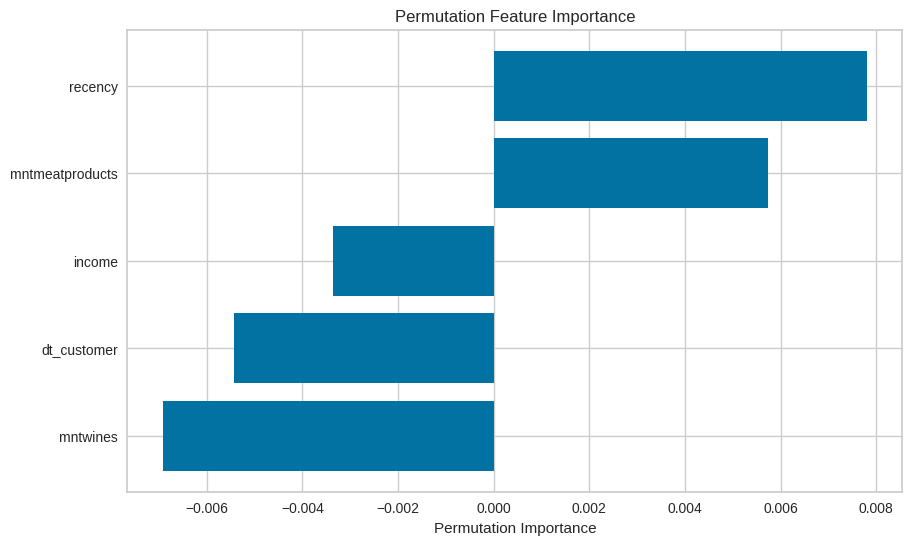

In [ ]:
# 4. Permutation Feature Importance

from pycaret.classification import get_config
from sklearn.inspection import permutation_importance
import numpy as np

# Recupera os dados transformados do PyCaret
X_test_transformed = get_config('X_test_transformed')
y_test = get_config('y_test')

# Calcula o permutation importance para o modelo afinado
result = permutation_importance(tuned_model, X_test_transformed, y_test, n_repeats=30, random_state=42)
sorted_idx = np.argsort(result.importances_mean)

# Tenta recuperar os nomes das features
try:
    feature_names = X_test_transformed.columns
except Exception:
    feature_names = np.array([f'feature_{i}' for i in range(X_test_transformed.shape[1])])

# Plota o gráfico de Permutation Importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(np.array(feature_names)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('Permutation Feature Importance')
plt.show()

## 5. Análise e Interpretação dos Resultados

Os resultados indicam que o modelo afinado (após o tuning) apresenta um ganho no AUC em comparação aos modelos anteriores.

- A normalização dos nomes e valores das features garantiu a consistência dos dados utilizados na modelagem, evitando erros.

- A engenharia de atributos, como a criação da variável `client_years`, trouxe informações adicionais relevantes para o modelo.

- A utilização de `compare_models()` e `tune_model()` permitiu selecionar e otimizar o modelo com melhor desempenho na métrica AUC.

- Os plots gerados (AUC, Matriz de Confusão e Permutation Importance) evidenciam a performance do modelo e a relevância das variáveis.

**Conclusões:**
- O pipeline de pré-processamento e normalização foi essencial para obter um modelo consistente;
- As transformações e a criação de novas features melhoraram a qualidade dos dados e o desempenho do modelo (AUC);
- O tuning de hiperparâmetros refinou ainda mais o modelo, demonstrando a eficácia das técnicas aplicadas.

## 6. Entrega

- **Participantes:** Alan de Souza Maximiano da Silva - RM557088 - 2TIAPY-2025
- **Repositório GitHub:** https://github.com/alansms/CP1_Front_End_-_Mobile_Deploy